In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.cluster import DBSCAN

In [2]:
df = pd.read_csv("./data/df_final_janeiro_22.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Freq_Depressao,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,2.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0


In [3]:
target_column = 'Autoavaliacao_Saude'

X = df.drop(columns=[target_column])
y = df[target_column]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA(n_components=3, svd_solver='randomized', random_state=42)
X_pca = pca.fit_transform(X_scaled)

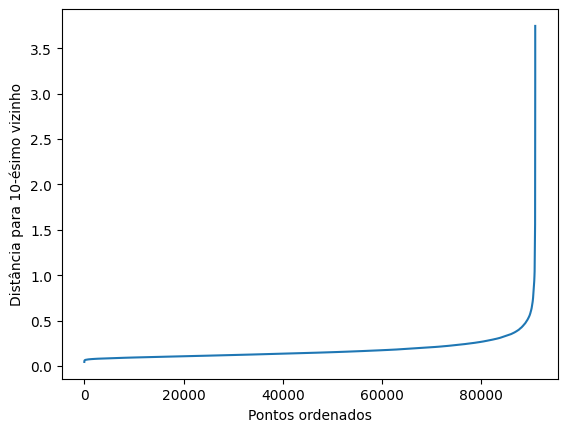

In [6]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:, k-1])
plt.plot(distances)
plt.ylabel(f"Distância para {k}-ésimo vizinho")
plt.xlabel("Pontos ordenados")
plt.show()


In [30]:
dbscan = DBSCAN(eps=0.15, min_samples=10)
clusters = dbscan.fit_predict(X_pca)
print(pd.Series(clusters).value_counts())

 0      55053
-1      31532
 65        91
 37        88
 6         86
        ...  
 103        4
 227        4
 69         3
 121        2
 226        2
Name: count, Length: 263, dtype: int64


In [31]:
sorted(set(clusters))

[np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.i

In [32]:
df['cluster'] = clusters

In [33]:
df['cluster'].value_counts()

cluster
 0      55053
-1      31532
 65        91
 37        88
 6         86
        ...  
 103        4
 227        4
 69         3
 121        2
 226        2
Name: count, Length: 263, dtype: int64

In [34]:
pure_clusters = []
for cluster_id in set(clusters):
    if cluster_id == -1:  
        continue
    cluster_data = df[df['cluster'] == cluster_id]
    counts = cluster_data[target_column].value_counts(normalize=True)
    if counts.max() >= 0.6:
        pure_clusters.append(cluster_id)
        print(cluster_id)

9
12
18
20
24
26
32
34
40
42
44
48
49
50
51
53
55
56
60
65
66
67
69
71
72
76
79
90
92
94
100
101
102
104
108
115
117
120
127
128
140
148
150
151
154
156
157
160
163
167
170
173
174
181
182
183
185
187
188
191
193
194
195
198
202
206
207
213
214
217
219
220
221
222
223
224
225
227
229
233
234
235
236
242
245
247
249
251
253
255
257
258
261


In [35]:
df_filtered = df[df['cluster'].isin(pure_clusters)]
df_filtered

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos,cluster
183,3.0,71.0,1.0,4.0,1.0,2.0,2.0,5.0,2.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,1.0,1.0,0.0,65
258,1.0,46.0,1.0,1.0,1.0,1.0,3.0,8.0,2.0,1.0,...,2.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,40
389,2.0,54.0,2.0,4.0,2.0,1.0,6.0,7.0,3.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0,261
582,2.0,42.0,2.0,4.0,2.0,1.0,2.0,4.0,1.0,1.0,...,2.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,3.0,202
670,2.0,68.0,1.0,4.0,2.0,1.0,5.0,7.0,3.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0,221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90300,3.0,52.0,1.0,4.0,2.0,1.0,6.0,6.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,3.0,207
90606,1.0,73.0,1.0,2.0,2.0,2.0,5.0,10.0,3.0,1.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,2.0,182
90638,3.0,53.0,2.0,4.0,4.0,1.0,1.0,5.0,1.0,2.0,...,2.0,2.0,2.0,2.0,6.0,3.0,1.0,0.0,3.0,102
90747,4.0,80.0,1.0,1.0,4.0,2.0,4.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,65


Autoavaliacao_Saude
1.0    144
2.0    640
3.0    457
4.0     62
5.0      9
Name: count, dtype: int64


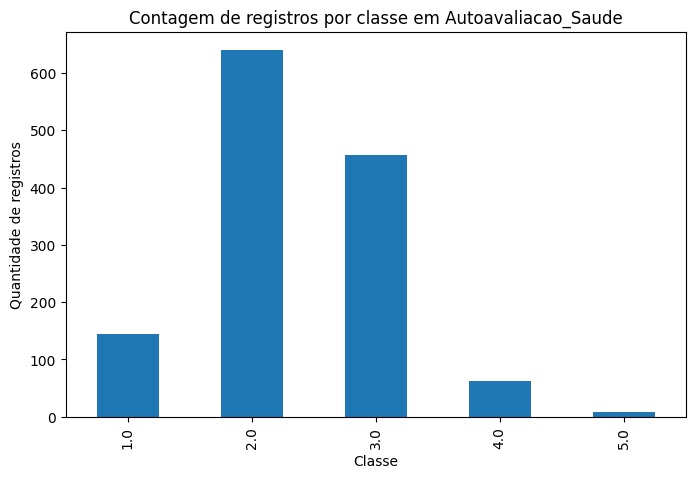

In [36]:
counts = df_filtered['Autoavaliacao_Saude'].value_counts().sort_index()

print(counts)

plt.figure(figsize=(8,5))
counts.plot(kind='bar')
plt.title('Contagem de registros por classe em Autoavaliacao_Saude')
plt.xlabel('Classe')
plt.ylabel('Quantidade de registros')
plt.show()

In [38]:
df_filtered.drop(columns=["cluster"])

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Freq_Depressao,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
183,3.0,71.0,1.0,4.0,1.0,2.0,2.0,5.0,2.0,1.0,...,1.0,2.0,2.0,2.0,1.0,3.0,3.0,1.0,1.0,0.0
258,1.0,46.0,1.0,1.0,1.0,1.0,3.0,8.0,2.0,1.0,...,1.0,2.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0
389,2.0,54.0,2.0,4.0,2.0,1.0,6.0,7.0,3.0,1.0,...,1.0,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0
582,2.0,42.0,2.0,4.0,2.0,1.0,2.0,4.0,1.0,1.0,...,2.0,2.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,3.0
670,2.0,68.0,1.0,4.0,2.0,1.0,5.0,7.0,3.0,1.0,...,1.0,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90300,3.0,52.0,1.0,4.0,2.0,1.0,6.0,6.0,1.0,2.0,...,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,3.0
90606,1.0,73.0,1.0,2.0,2.0,2.0,5.0,10.0,3.0,1.0,...,1.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,2.0
90638,3.0,53.0,2.0,4.0,4.0,1.0,1.0,5.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,6.0,3.0,1.0,0.0,3.0
90747,4.0,80.0,1.0,1.0,4.0,2.0,4.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0


In [40]:
df_filtered.to_csv("./data/df_filtrado_pelo_dbcsan.csv", index=False)